# PHÁT HIỆN DỊ THƯỜNG TRONG DỮ LIỆU CHUỖI THỜI GIAN COVID-19

In [20]:
import sys
import os
sys.path.append(os.path.abspath('../src/time_series'))
sys.path.append(os.path.abspath('../src'))

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from dataset import TimeSeriesDataset
from preprocessing_detect_outlier import DetectOutlierTimeSeries
from visualization.comparison import plot_anomalies_all_methods

warnings.filterwarnings('ignore')

## 1. Cơ sở lý thuyết
### 1.1. Thế nào là điểm bất thường trong dữ liệu Covid-19?
Trong chuỗi thời gian Covid-19 (ví dụ như số ca nhiễm mới hàng ngày), **điểm bất thường (Anomaly/Outlier)** là những quan sát lệch khỏi quy luật vận động tự nhiên của dịch bệnh hoặc quy trình báo cáo y tế.
- **Dị thường do lỗi hệ thống (Data Dumping):** Do việc dồn báo cáo từ nhiều ngày vào một ngày duy nhất (thường thấy vào đầu tuần), tạo ra các cột dữ liệu cao đột biến không phản ánh đúng tốc độ lây nhiễm thực tế.
- **Dị thường do biến cố thực tế:** Sự xuất hiện của một biến chủng mới hoặc một sự kiện siêu lây nhiễm khiến số ca tăng vọt ra ngoài xu hướng hiện tại.
- **Dị thường do bối cảnh (Contextual):** Một ngày có 500 ca nhiễm là bình thường nếu đang ở đỉnh dịch, nhưng là dị thường nếu dịch đang trong giai đoạn kiểm soát tốt.

### 1.2. Dùng Z-score trên dữ liệu Deseasonalized
Ở đây, dữ liệu Covid-19 có tính chu kỳ tuần (Weekly Seasonality) rất mạnh: số ca báo cáo vào cuối tuần thường thấp và tăng vọt vào thứ Hai/thứ Ba do độ trễ hành chính.

Vấn đề có thể xảy ra khi dùng Z-score ($Z = \frac{x - \mu}{\sigma}$) trực tiếp trên dữ liệu gốc, vì khi đó các ngày thứ Hai thường xuyên bị đánh dấu là dị thường vì chúng luôn cao hơn trung bình, dù đó chỉ là quy luật hàng tuần.

Vì vậy, dữ liệu cần được **loại bỏ đi tính mùa vụ (Deseasonalized)** để Z-score có thể phát hiện được điểm bất thường, cụ thể: 
- Khi loại bỏ tính mùa vụ, ta **lấy dữ liệu gốc trừ đi thành phần chu kỳ ($Y_t - S_t$)**, và thu được thành phần dư thừa (Residual/Noise).
- Từ đó, khi tính Z-score áp dụng trên Residual trên chuỗi đã khử chu kỳ này, ta đang so sánh sự biến động của ngày hôm đó với mức nền thực tế (đã loại bỏ nhiễu hành chính), và khi đó thực sự phản ánh một sự biến động bất thường về dịch tễ hoặc lỗi nhập liệu nghiêm trọng, chứ không phải do hiệu ứng "ngày thứ Hai" như đã đề cập. Với điểm có $|Z| > threshold$ (thường là 3), điểm đó sẽ được coi là dị thường.

### 1.3. Các bước phát hiện dị thường của Isolation Forest
Isolation Forest sẽ tập trung vào việc cô lập điểm dữ liệu.

**Các bước thực hiện:**
- **Lấy mẫu ngẫu nhiên (Sampling)**: Chọn một tập con dữ liệu từ cửa sổ thời gian của chuỗi Covid-19.
- **Phân tách nhị phân (Random Splitting)**:
  * Chọn ngẫu nhiên một đặc trưng (ví dụ: New_cases).
  * Chọn ngẫu nhiên một giá trị cắt giữa Min và Max của đặc trưng đó.
- **Xây dựng cây cô lập (iTree)**: Lặp lại việc chia tách cho đến khi điểm dữ liệu hoàn toàn bị cô lập trong một nút lá.
- **Đánh giá độ dài đường đi (Path Length)**:
  * Điểm dị thường (số ca quá cao hoặc quá thấp) thường nằm xa đám đông nên dễ bị cô lập hơn $\rightarrow$ Đường đi từ gốc đến lá **ngắn**.
  * Điểm bình thường nằm cụm với nhau $\rightarrow$ Cần nhiều lần cắt mới cô lập được $\rightarrow$ Đường đi **dài**.
- **Tính Anomaly Score**: Kết hợp kết quả từ nhiều cây để đưa ra xác suất dị thường.

### 1.4. Các bước phát hiện dị thường dựa trên STL Residual Thresholding
Phương pháp này dựa trên việc phân rã chuỗi thời gian để tìm ra những sai số không thể giải thích được bằng quy luật.

**Các bước thực hiện:**
- **Phân rã STL (Seasonal-Trend decomposition using LOESS):** Tách chuỗi gốc $Y_t$ thành 3 thành phần:
  $$Y_t = T_t (\text{Trend}) + S_t (\text{Seasonality}) + R_t (\text{Residual})$$

- **Trích xuất Residual:** Tập trung hoàn toàn vào thành phần $R_t$ (phần dư). Đây là nơi chứa đựng các nhiễu trắng và các biến động bất thường.
- **Tính toán ngưỡng (Thresholding):** Xác định ngưỡng biên cho $R_t$ bằng các phương pháp thống kê:
  * Ngưỡng $3\sigma$: $[\mu - 3\sigma, \mu + 3\sigma]$.
  * Ngưỡng IQR: Sử dụng khoảng cách liên tứ phân vị để xác định các điểm nằm ngoài whisker của biểu đồ hộp Boxplot.
- **Đánh dấu dị thường:** Bất kỳ thời điểm $t$ nào có $|R_t|$ vượt ra ngoài ngưỡng đã thiết lập sẽ được gắn nhãn là điểm dị thường.

Đối với dữ liệu Covid-19, phương pháp **STL** thường ổn định hơn **Z-score** vì nó xử lý tốt cả **Xu hướng (Trend)** đang tăng nhanh và **Chu kỳ (Seasonality)** lặp lại, giúp việc phát hiện dị thường không bị lệch theo độ dốc của biểu đồ.

## 2. Thực nghiệm và nhận xét
### 2.1. Định hình bài toán và dữ liệu
Chúng ta sẽ xác định xem các điểm bất thường trong dữ liệu Covid-19 là do biến cố dịch tễ thực tế (bùng dịch, nới lỏng giãn cách) hay chỉ là nhiễu dữ liệu (dồn báo cáo cuối tuần, điều chỉnh lại số liệu).

**Về phạm vi dữ liệu:** 

- **Biến phân tích (Target Variables):** Lựa chọn phân tích số ca mắc mới (`New_cases`) và số ca tử vong mới (`New_deaths`). Lý do: Dữ liệu tích lũy (`Confirmed`, `Deaths`) mang tính chất chuỗi không dừng (Non-stationary) và có xu hướng tăng liên tục, rất khó để các thuật toán bắt được sự đột biến cục bộ. Việc lấy sai phân để tìm số ca mới mỗi ngày là bắt buộc.

- **Khu vực lựa chọn (Countries of Interest):** Để so sánh độ hiệu quả của thuật toán trên các hình thái phân phối khác nhau, ta chọn 4 quốc gia đại diện:
  + **US (Mỹ):** Khối lượng dữ liệu khổng lồ, bùng phát nhiều làn sóng rõ rệt.
  + **Italy (Ý):** Tâm dịch đầu tiên tại Châu Âu, thể hiện sự hoảng loạn dữ liệu giai đoạn đầu.
  + **Vietnam (Việt Nam):** Điển hình cho nhóm kiểm soát cực tốt giai đoạn đầu nhưng bùng nổ mạnh ở giai đoạn sau (Delta wave).
  + **Brazil:** Nổi tiếng với nhiều vấn đề trong khâu ghi nhận và báo cáo dữ liệu y tế, kỳ vọng sẽ có nhiều dữ liệu nhiễu.

In [22]:
TARGET_COUNTRIES = ['US', 'Italy', 'Vietnam', 'Brazil']
DATA_PATH = '../data/time_series/time-series-19-covid-combined.csv' 

In [23]:
# Load dữ liệu 
try:
    df_raw = pd.read_csv(DATA_PATH)
    if 'Country/Region' in df_raw.columns:
        df_raw.rename(columns={'Country/Region': 'Country'}, inplace=True)
    if 'ObservationDate' in df_raw.columns:
        df_raw.rename(columns={'ObservationDate': 'Date'}, inplace=True)
        
    df_raw['Date'] = pd.to_datetime(df_raw['Date'])
    print(f"Tổng số bản ghi ban đầu: {len(df_raw)}")
except Exception as e:
    print(f"[LỖI] Không thể tải dữ liệu: {e}")

Tổng số bản ghi ban đầu: 72090


Dữ liệu nguyên bản thường lưu trữ dạng cộng dồn (Cumulative). Ta sẽ thực hiện một hàm tiền xử lý với các bước sau:
- **Gộp dữ liệu (Aggregation):** Nhiều quốc gia (như Mỹ) được chia nhỏ thành các bang/tỉnh. Ta cần `groupby` theo Ngày và Quốc gia để lấy tổng số ca toàn quốc.
- **Lấy sai phân (Differencing):** Ta sẽ dùng hàm `.diff()` để tính số ca mắc/tử vong mới mỗi ngày.
- **Làm sạch nhiễu kỹ thuật (Data Cleaning):** Trong thực tế thống kê y tế, đôi khi các quốc gia thanh tra lại dữ liệu và trừ đi số ca khai khống trước đó, dẫn đến việc sai phân bị âm. Mặc dù đây là một dạng dị thường, nhưng nó là lỗi logic toán học. Ta sẽ giới hạn các giá trị âm về 0 hoặc nội suy bằng `bfill/ffill`.

In [24]:
def prepare_daily_data(df, countries):
    """Hàm trích xuất số ca mới hàng ngày từ dữ liệu tích lũy."""
    df_filtered = df[df['Country'].isin(countries)].copy()
    
    # Gộp tổng số liệu các tỉnh/bang thành số liệu cấp quốc gia theo ngày
    df_grouped = df_filtered.groupby(['Country', 'Date'])[['Confirmed', 'Deaths']].sum().reset_index()
    df_grouped = df_grouped.sort_values(by=['Country', 'Date'])
    
    # Tính sai phân (Daily New Cases/Deaths)
    df_grouped['New_cases'] = df_grouped.groupby('Country')['Confirmed'].diff().fillna(0)
    df_grouped['New_deaths'] = df_grouped.groupby('Country')['Deaths'].diff().fillna(0)
    
    # Xử lý các giá trị âm (Lỗi báo cáo y tế)
    negative_cases = len(df_grouped[df_grouped['New_cases'] < 0])
    print(f"[INFO] Phát hiện và xử lý {negative_cases} ngày có số ca mắc mới bị âm (Data Correction).")
    
    df_grouped['New_cases'] = df_grouped['New_cases'].clip(lower=0)
    df_grouped['New_deaths'] = df_grouped['New_deaths'].clip(lower=0)
    
    return df_grouped

Tiến hành thực thi trích xuất

In [25]:
# Thực thi trích xuất
df_daily = prepare_daily_data(df_raw, TARGET_COUNTRIES)
display(df_daily.tail())

[INFO] Phát hiện và xử lý 1 ngày có số ca mắc mới bị âm (Data Correction).


,Country,Date,Confirmed,Deaths,New_cases,New_deaths
1075,Vietnam,2020-10-13,1113,35,3.0,0.0
1076,Vietnam,2020-10-14,1122,35,9.0,0.0
1077,Vietnam,2020-10-15,1124,35,2.0,0.0
1078,Vietnam,2020-10-16,1124,35,0.0,0.0
1079,Vietnam,2020-10-17,1126,35,2.0,0.0


Trước khi đi vào phân tích sâu hơn, ta sẽ vẽ biểu đồ chuỗi thời gian cho biến `New_cases` của 4 quốc gia đã chọn.

In [26]:
def plot_baseline_scoping(df, countries, target_col='New_cases'):
    """Vẽ biểu đồ chuỗi thời gian tổng quan để nhận diện hình thái dữ liệu."""
    plt.figure(figsize=(16, 10))
    
    for i, country in enumerate(countries, 1):
        plt.subplot(2, 2, i)
        df_country = df[df['Country'] == country]
        
        plt.plot(df_country['Date'], df_country[target_col], 
                 color='steelblue', linewidth=1.5, alpha=0.8)
        
        plt.title(f'{country} - Daily {target_col}', fontsize=12, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Count')
        plt.grid(True, linestyle='--', alpha=0.5)
        
        plt.xticks(rotation=45)
        
    plt.tight_layout()
    plt.show()

Tiến hành trực quan hoá

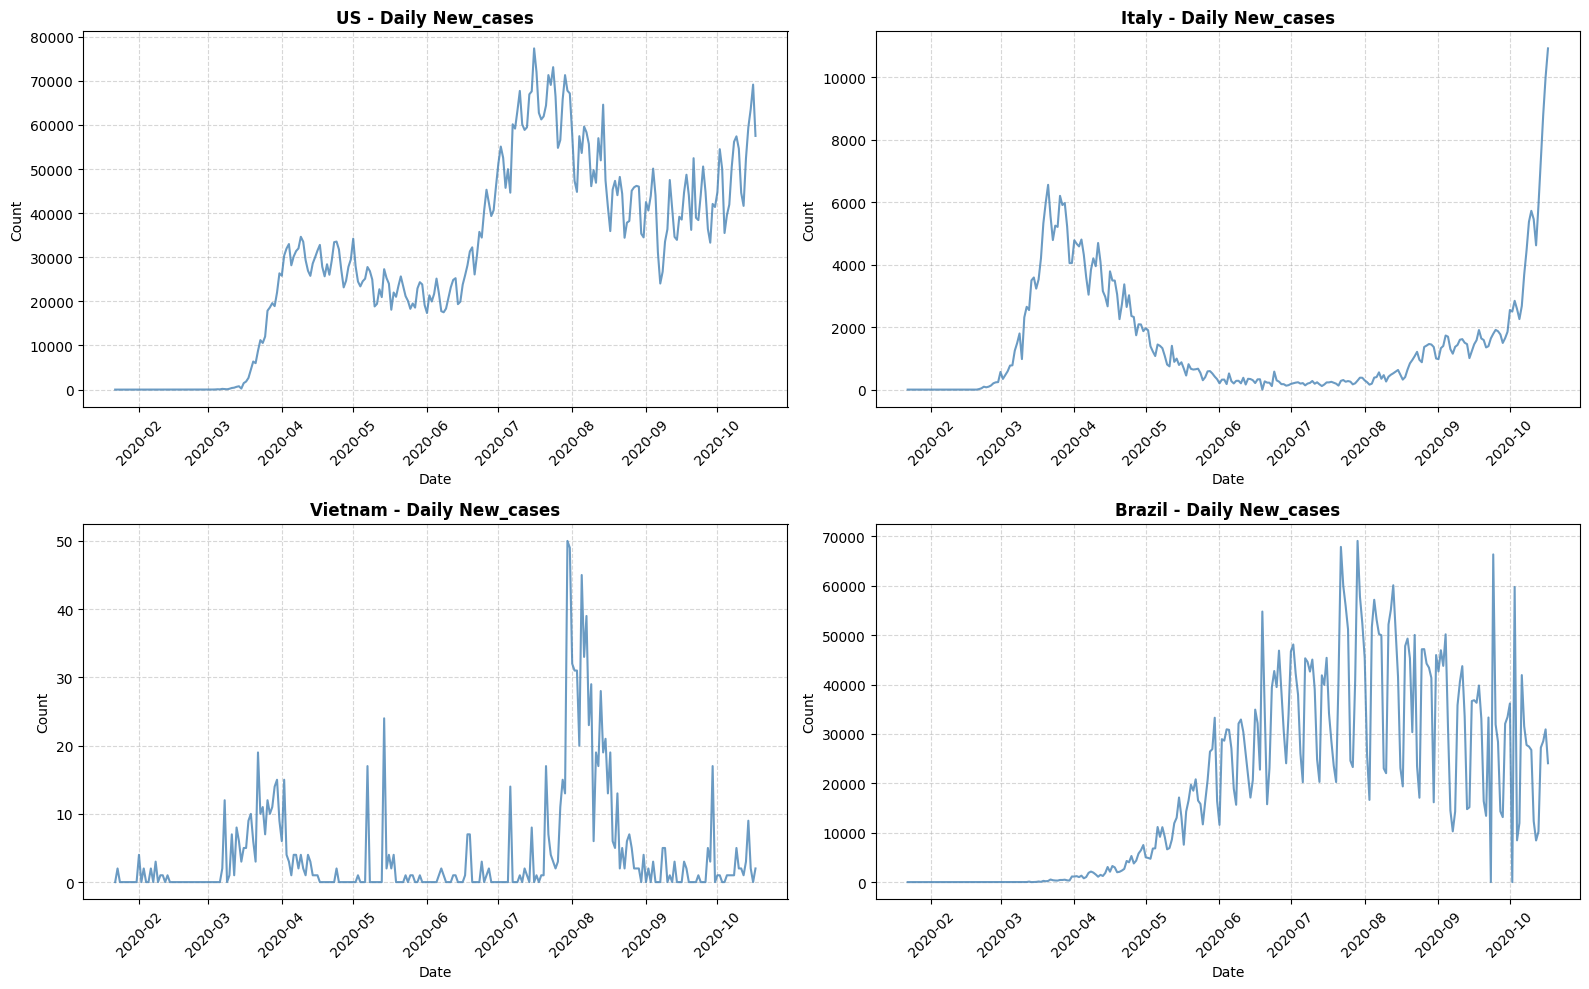

In [27]:
plot_baseline_scoping(df_daily, TARGET_COUNTRIES, target_col='New_cases')

Biểu đồ này phản ánh cực kỳ rõ nét đặc thù dữ liệu của 4 khu vực trong giai đoạn từ đầu năm 2020 đến khoảng tháng 10/2020. Cụ thể:
- Phân tích chi tiết từng quốc gia
    + Đường biểu diễn của **Mỹ** dao động với biên độ lớn theo hình răng cưa liên tục. Đây là minh chứng rõ nhất cho tính chu kỳ tuần (Weekly Seasonality) do độ trễ báo cáo (cuối tuần số ca giảm sâu, thứ 2/thứ 3 tăng vọt).
    + Đường biểu diễn của **Ý** thể hiện cấu trúc dịch tễ rất rõ ràng với 2 làn sóng: Làn sóng 1 vào tháng 3/tháng 4 và Làn sóng 2 với đợt bùng phát mạnh bắt đầu từ tháng 10. Giai đoạn giữa (tháng 6 - tháng 8) thì dữ liệu không có nhiều biến động đáng kể. Với dạng dữ liệu có xu hướng thay đổi đột ngột như thế này, phương pháp phân rã cấu trúc (STL) sẽ hoạt động cực kỳ hiệu quả để bắt được những ngày bùng dịch thực sự.
    + Biểu đồ của **Việt Nam** gần như là một đường thẳng bám sát trục hoành (0 ca), chỉ có những gợn sóng cực nhỏ (chỉ khoảng vài chục ca trong đợt dịch Đà Nẵng tháng 7/2020). Vì biểu đồ dùng chung tỷ lệ trục tung (hoặc tỷ lệ quá lớn so với số ca của VN) nên đường line bị ép dẹt.Có thể thấy, dữ liệu có phương sai cực thấp. Đối với VN trong năm 2020, một ngày có 50 ca mắc mới về mặt toán học đã là một điểm dị thường khổng lồ so với mức trung bình gần bằng 0. Thuật toán có độ nhạy cao sẽ vạch ra rất nhiều dị thường ở đoạn này.
    + Còn với **Brazil**, sau giai đoạn tăng dốc, số ca duy trì ở mức đỉnh nhưng dao động cực kỳ mạnh (từ 20.000 có thể giật lên 60.000 rồi rớt xuống ngay hôm sau). Nhìn vào khoảng đen đặc trên biểu đồ, có thể thấy dữ liệu rất bẩn (Data Dumping - dấu hiệu của việc dồn báo cáo). Isolation Forest sẽ là lựa chọn tiềm năng nhất ở biểu đồ này vì nó cô lập những điểm giật cục này rất tốt.
- Tổng kết lại, ta thấy dữ liệu có tính chất **non-stationary** rõ rệt: Dù đã lấy sai phân (`New Cases`), ta vẫn thấy rõ kỳ vọng và phương sai thay đổi liên tục theo thời gian ở Mỹ, Ý và Brazil. Ngoài ra, nhìn vào sự khác biệt giữa Mỹ (biến động hàng chục ngàn ca) và Việt Nam (biến động vài chục ca), ta không thể dùng một ngưỡng tĩnh cố định (như số ca > 10.000 là bất thường) cho tất cả các nước. Ta bắt buộc phải dùng các phương pháp mang tính tương đối (như Z-score chuẩn hóa, Thresholding dựa trên IQR, hoặc Cây cô lập) để khi phân tích cho mỗi quốc gia có thể tự đưa ra ngưỡng dị thường của riêng mình.

### 2.2. Pipeline phát hiện dị thường
Mục tiêu của pipeline sẽ là cài đặt 3 phương pháp phát hiện dị thường chính như sau:
- **Z-score**: Áp dụng trên chuỗi đã khử mùa vụ (Deseasonalized).
- **Isolation Forest**: Áp dụng cơ chế cửa sổ trượt (Sliding Window) với `W=7`, `contamination='auto'`.
- **STL Residual Thresholding**: Dựa trên ngưỡng của thành phần dư (Residual) sau khi phân rã.

In [9]:
# Cấu hình danh sách thực nghiệm
TARGET_COUNTRIES = ['US', 'Italy', 'Vietnam', 'Brazil']
METHODS = ['z-score', 'iforest', 'stl']
WINDOW_SIZES = [3, 7, 14, 30] 

def run_anomaly_detection_pipeline(df, countries, method, window=7):
    """
    Hàm thực thi pipeline cho một phương pháp cụ thể trên danh sách quốc gia.
    """
    results = {}
    for country in countries:
        df_country = df[df['Country'] == country].copy()
        
        dataset = TimeSeriesDataset(path=None, time_column='Date')
        dataset.data = df_country
        dataset.set_target(target_column='New_cases')
        
        detector = DetectOutlierTimeSeries(method=method, window_size=window, contamination='auto')
        dataset.accept(detector)
        
        results[country] = detector.get_anomaly_mask()
        
    return results

Chúng ta tiến hành khởi chạy hàm `run_anomaly_detection_pipeline` để thu thập kết quả của 3 phương pháp và lưu trên Pivot Table.

In [10]:
all_masks = {method: {} for method in METHODS}

summary_counts = []

old_stdout = sys.stdout
with open(os.devnull, 'w') as f:
    for method in METHODS:
        sys.stdout = old_stdout
        print(f"[*] Đang thực thi phương pháp: {method.upper()}...")
        sys.stdout = f
        
        method_results = run_anomaly_detection_pipeline(
            df=df_daily, 
            countries=TARGET_COUNTRIES, 
            method=method, 
            window=7
        )
        
        for country, mask in method_results.items():
            all_masks[method][country] = mask
            summary_counts.append({
                'Method': method.upper(),
                'Country': country,
                'Anomalies_Count': mask.sum()
            })
sys.stdout = old_stdout

print("BẢNG TỔNG HỢP SỐ LƯỢNG ĐIỂM DỊ THƯỜNG PHÁT HIỆN ĐƯỢC:\n")

df_summary_pipeline = pd.DataFrame(summary_counts)
pivot_summary = df_summary_pipeline.pivot(index='Country', columns='Method', values='Anomalies_Count')

pivot_summary = pivot_summary[['Z-SCORE', 'IFOREST', 'STL']]
display(pivot_summary)

[*] Đang thực thi phương pháp: Z-SCORE...
[*] Đang thực thi phương pháp: IFOREST...
[*] Đang thực thi phương pháp: STL...
BẢNG TỔNG HỢP SỐ LƯỢNG ĐIỂM DỊ THƯỜNG PHÁT HIỆN ĐƯỢC:



Method,Z-SCORE,IFOREST,STL
Country,,,
Brazil,0,52,89
Italy,4,54,60
US,0,56,39
Vietnam,5,29,63


Sử dụng hàm `plot_anomalies_all_methods` để vẽ biểu đồ chuỗi thời gian cho từng quốc gia. Trên mỗi biểu đồ, ta sẽ overlay các điểm dị thường được phát hiện bởi cả 3 phương pháp: Z-score, Isolation Forest và STL.


[*] Đang vẽ biểu đồ so sánh cho khu vực: US


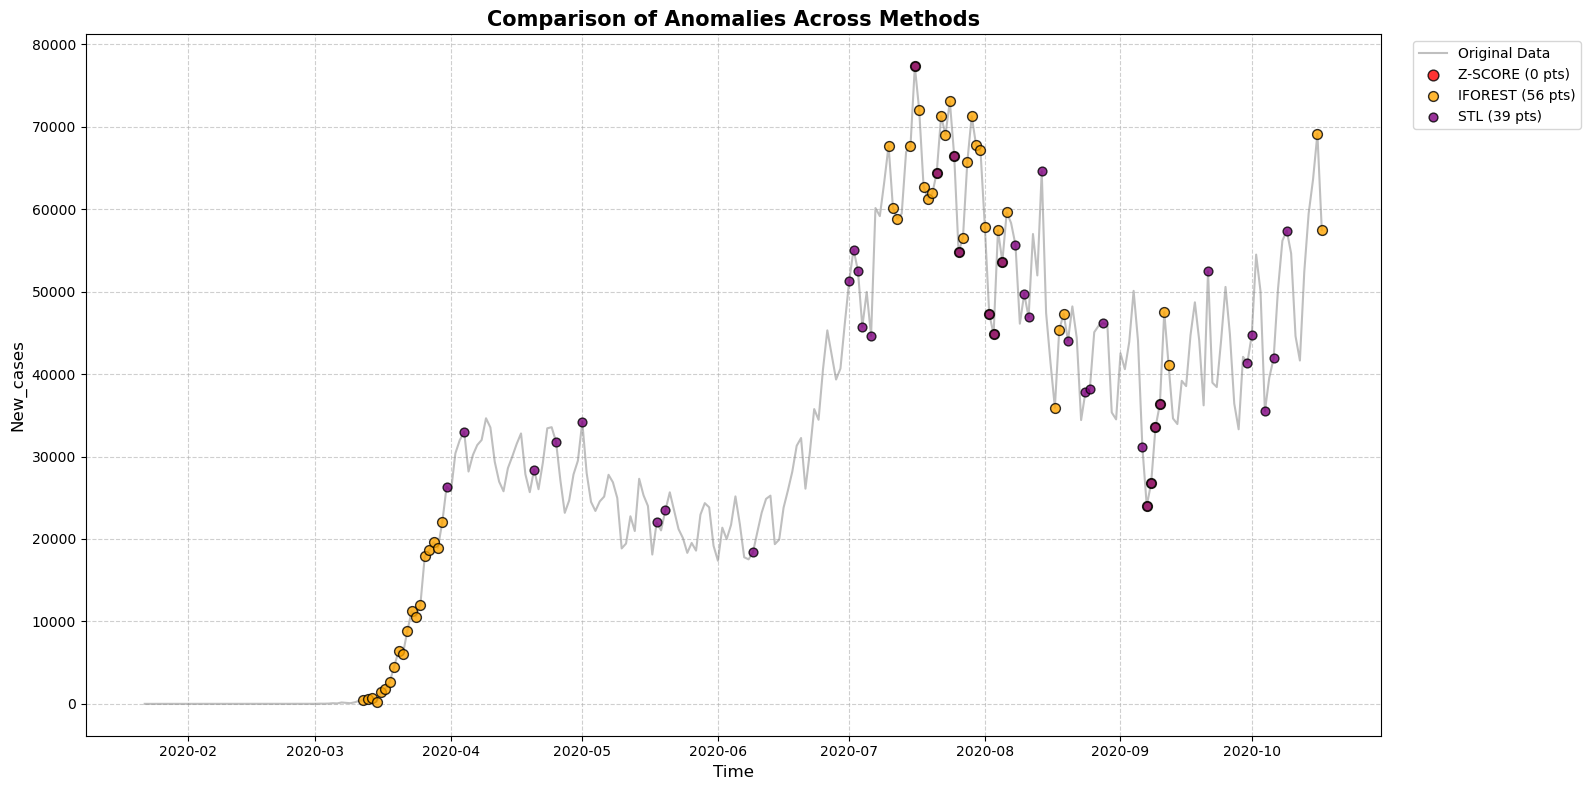


[*] Đang vẽ biểu đồ so sánh cho khu vực: ITALY


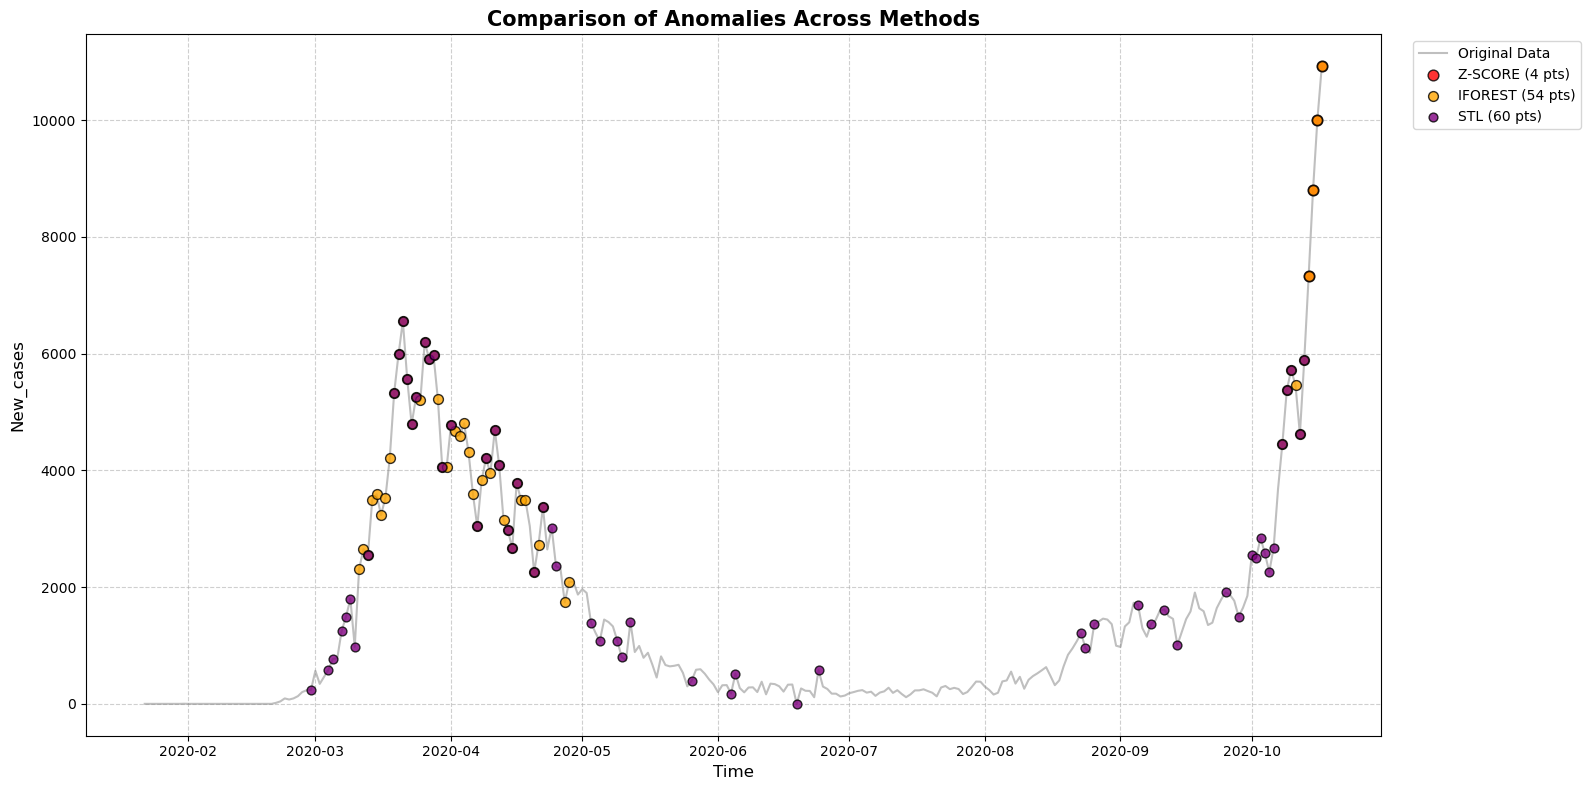


[*] Đang vẽ biểu đồ so sánh cho khu vực: VIETNAM


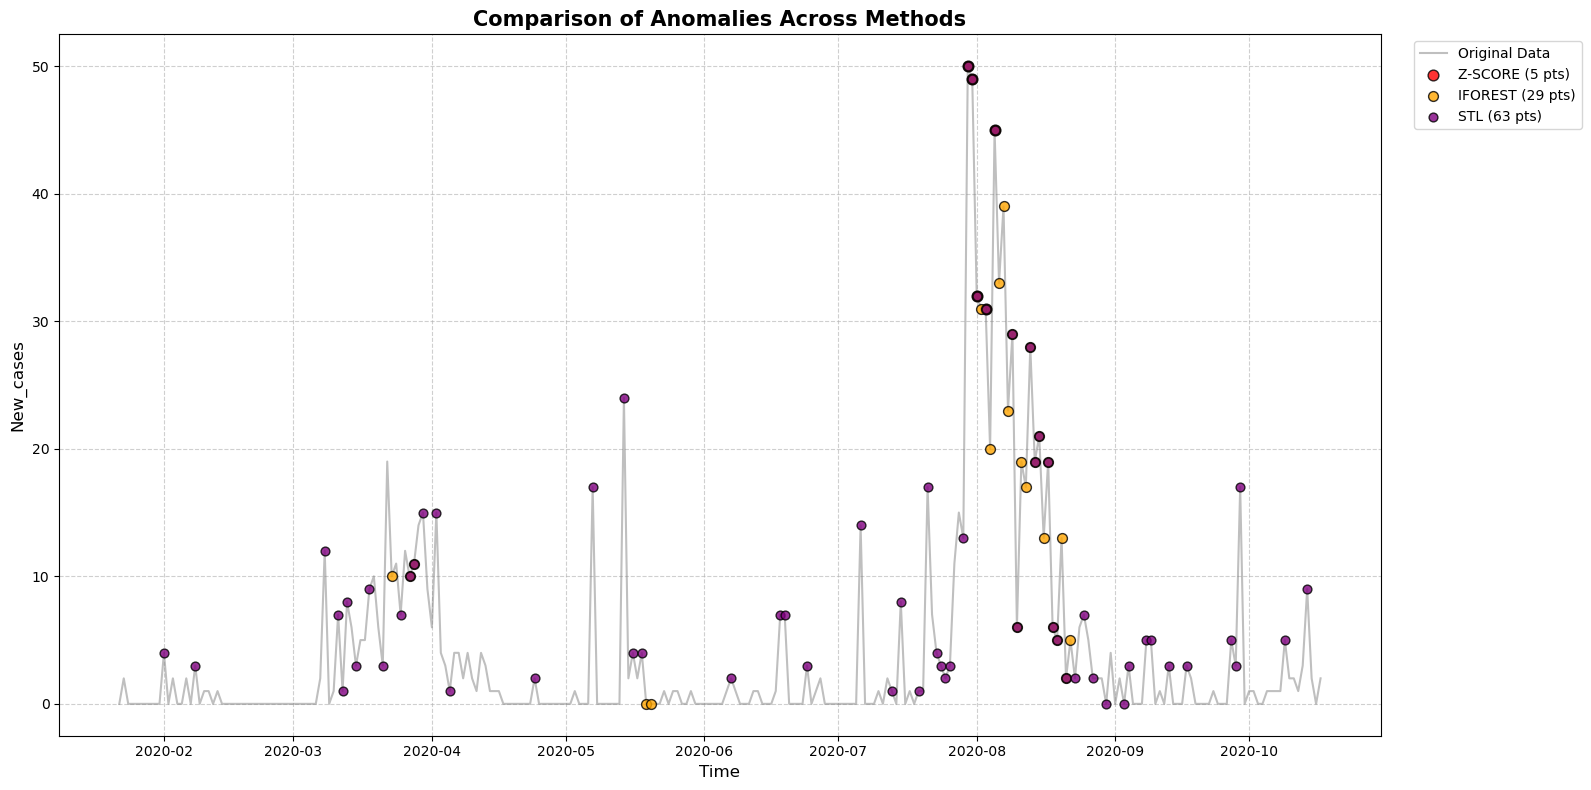


[*] Đang vẽ biểu đồ so sánh cho khu vực: BRAZIL


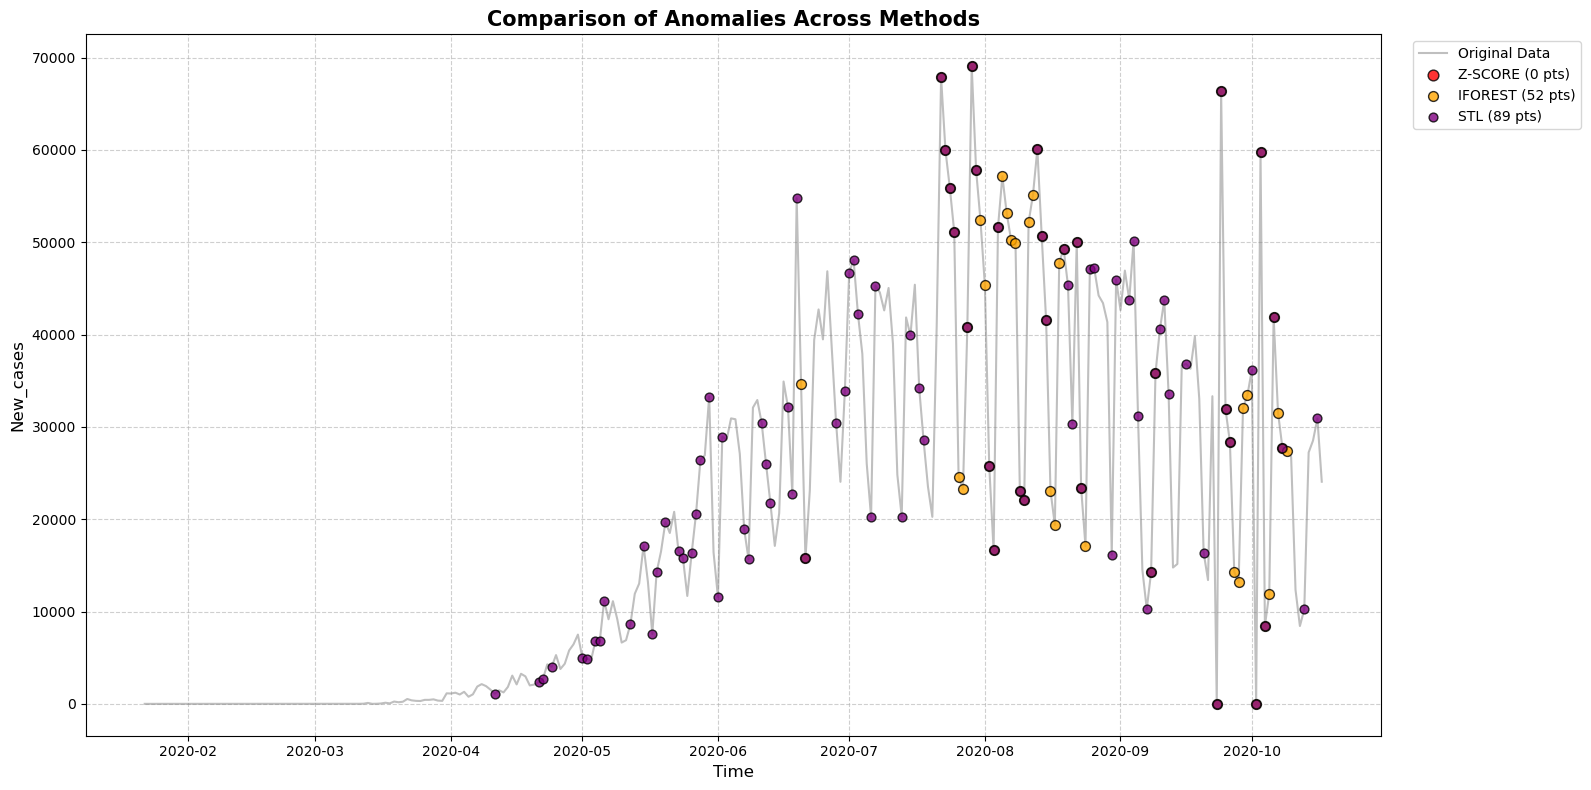

In [11]:
for country in TARGET_COUNTRIES:
    print(f"\n[*] Đang vẽ biểu đồ so sánh cho khu vực: {country.upper()}")
    
    df_country = df_daily[df_daily['Country'] == country].copy()
    
    dataset_viz = TimeSeriesDataset(path=None, time_column='Date')
    dataset_viz.data = df_country
    dataset_viz.set_target(target_column='New_cases')
    
    anomalies_dict = {
        'Z-SCORE': all_masks['z-score'][country],
        'IFOREST': all_masks['iforest'][country],
        'STL': all_masks['stl'][country]
    }
    
    try:
        plot_anomalies_all_methods(dataset=dataset_viz, anomalies_dict=anomalies_dict)
    except Exception as e:
        print(f"[LỖI] Không thể vẽ biểu đồ cho {country}: {e}")

Nhìn vào biểu đồ, có thể thấy: 
- **Z-score** thể hiện độ tin cậy cực thấp. Vì bản chất của nó là sử dụng ngưỡng tĩnh dựa trên trung bình toàn bộ chuỗi dữ liệu, vậy nên với một bộ dữ liệu có sự biến động về quy mô ca nhiễm rất mạnh mẽ theo thời gian (ví dụ như số ca nhiễm ở các tháng sau lại tăng vọt gấp hàng chục lần giai đoạn đầu), **Z-score** sẽ bỏ sót hầu hết các làn sóng dịch quan trọng.
- **STL Residual Thresholding** lại có 1 hạn chế nhất định ở thành phần **Trend**. Vì thành phần này được thiết kế để uốn lượn và bám sát những thay đổi lớn, nên khi dịch bùng phát (ví dụ như số ca tăng từ 100 lên 10000), **STL** lại coi đó là một xu hướng mới của dữ liệu chứ không phải là một điểm dị thường, dẫn đến **Trend** cũng thay đổi tỉ lệ thuận theo sự tăng của dữ liệu này. Điều này làm cho giá trị **Residual** khi tính toán thường rất nhỏ và rời rạc, mà rõ ràng bản chất của **STL** khi phát hiện dị thường lại so sánh giá trị **Residual** có vượt ngưỡng đã thiết lập hay không. Vậy nên, phương pháp này không thể hiện được tính chất của một giai đoạn bùng phát dịch mạnh ở một giai đoạn nhất định nào đó. Phân tích này cũng khẳng định rằng với ngưỡng trên **Residual** của **STL**, các điểm dị thường không thể đánh dấu được các đợt bùng dịch.
- **Isolation Forest** lại có độ tin cậy cao hơn khi có thể nhận diện dị thường dựa trên sự cô lập của các điểm có phương sai và mật độ biến động lớn. Đây là phương pháp rất hiệu quả để bám sát được các làn sóng dịch một cách rõ ràng như biểu đồ đã thể hiện. Thuật toán đã khoanh vùng chính xác các clusters dị thường dày đặc tại những tháng có sự thay đổi pha đột ngột (như tháng 3 và tháng 7 năm 2020 ở Mỹ chẳng hạn). Sự tràn lan các điểm dị thường trong các tháng này chính là bằng chứng toán học phản ánh đúng trạng thái bùng phát dữ dội của dịch bệnh trong thực tế.

### 2.3. Tối ưu hoá kích thước cửa số cho Isolation Forest
Ở pipeline phát hiện dị thường trên, khi áp dụng cơ chế cửa số trượt trong **Isolation Forest** chúng ta lại áp dụng cấu hình `W = 7`. Cấu hình này dựa trên kết quả tunning với các chỉ số bên dưới đại diện cho tầm nhìn của thuật toán như sau: 
- $W = 3$: Tầm nhìn cực ngắn, dễ bị nhiễu bởi dao động ngày qua ngày.
- $W = 7$: Tầm nhìn chu kỳ tuần, bám sát nhịp độ báo cáo hành chính.
- $W = 14$: Tầm nhìn chu kỳ ủ bệnh (2 tuần).
- $W = 30$: Tầm nhìn dài hạn theo xu hướng tháng.

In [12]:
tuning_results = []
tuning_masks_dict = {country: {} for country in TARGET_COUNTRIES}

for country in TARGET_COUNTRIES:
    df_country = df_daily[df_daily['Country'] == country].copy()
    
    dataset_tuning = TimeSeriesDataset(path=None, time_column='Date')
    dataset_tuning.data = df_country
    dataset_tuning.set_target(target_column='New_cases')
    
    for w in WINDOW_SIZES:
        detector = DetectOutlierTimeSeries(method='iforest', window_size=w, contamination='auto')
        
        old_stdout = sys.stdout
        with open(os.devnull, 'w') as f:
            sys.stdout = f
            try:
                dataset_tuning.accept(detector)
                mask = detector.get_anomaly_mask()
            finally:
                sys.stdout = old_stdout 
                
        num_anomalies = mask.sum()
        tuning_masks_dict[country][f'W={w}'] = mask
        
        tuning_results.append({
            'Country': country,
            'Window_Size': f'W = {w:02d}',
            'Anomalies_Count': num_anomalies
        })

Ta có kết quả tổng quát về số lượng điểm dị thường phát hiện được theo từng kích thước cửa sổ như đã đề cập trên từng quốc gia như sau

In [13]:
df_tuning = pd.DataFrame(tuning_results)
pivot_tuning = df_tuning.pivot(index='Country', columns='Window_Size', values='Anomalies_Count')

print("Số lượng điểm dị thường phát hiện được theo từng kích thước cửa sổ:\n")
display(pivot_tuning)

Số lượng điểm dị thường phát hiện được theo từng kích thước cửa sổ:



Window_Size,W = 03,W = 07,W = 14,W = 30
Country,,,,
Brazil,50,52,61,69
Italy,52,54,58,63
US,52,56,54,69
Vietnam,57,29,28,35


Kết quả này đủ để giải thích được lí do $W = 7$ là kích thước ổn định nhất cho **Isolation Forest**: 
- Nếu chọn $W = 3$, việc phát hiện dị thường có thể bị sai lệch ở hiện tượng giảm xét nghiệm và báo cáo vào Thứ Bảy, Chủ Nhật và công bố bù vào Thứ Hai, Thứ Ba, bởi các ca mắc mới vào đầu tuần có thể bị quá cao so với kết quả ở cuối tuần. Vậy nên, chu kỳ 7 ngày như $W = 7$ thể hiện có thể làm cho thuật toán nhận diện các biến động lên xuống trong tuần là bình thường, từ đó chỉ tập trung bắt được các dị thường thực sự liên quan đến dịch tễ.
- Ở $W = 14$ hay $W = 30$, thuật toán sẽ so sánh dữ liệu hiện tại với dữ liệu của cả tháng trước hay nửa tháng trước. Điều này không hợp lý trong bối cảnh dịch bệnh có sự biến động rất lớn về số ca mắc theo từng ngày, việc dùng dữ liệu quá cũ sẽ làm mờ đi các biến động mới, khiến thuật toán phản ứng chậm chạp và nhận diện dị thường tràn lan khi dịch chuyển sang một pha mới (đạt đỉnh hoặc đi xuống).

### 2.4. Phân tích sự trùng nhau giữa 3 phương pháp và Đặc điểm của những điểm dị thường chỉ xuất hiện ở 1 phương pháp
Trong phần này, chúng ta sẽ thực hiện phân tích tập hợp (Set Analysis) để xác định mức độ đồng thuận giữa ba phương pháp: **Z-score**, **Isolation Forest**, và **STL Residual**. Việc này giúp làm rõ liệu các phương pháp có đang bắt cùng một loại dị thường hay mỗi phương pháp đang tập trung vào một đặc điểm dữ liệu riêng biệt.

In [14]:
def calculate_anomaly_overlap(masks, countries):
    """
    Calculates unique and overlapping anomalies across three methods.
    Returns a DataFrame with columns for reporting.
    """
    overlap_results = []
    
    for country in countries:
        m_z = masks['z-score'][country]
        m_if = masks['iforest'][country]
        m_stl = masks['stl'][country]
        
        all_three = (m_z & m_if & m_stl).sum()
        if_stl_only = (m_if & m_stl & ~m_z).sum()
        if_z_only = (m_if & m_z & ~m_stl).sum()
        stl_z_only = (m_stl & m_z & ~m_if).sum()
        
        if_unique = (m_if & ~m_stl & ~m_z).sum()
        stl_unique = (m_stl & ~m_if & ~m_z).sum()
        z_unique = (m_z & ~m_if & ~m_stl).sum()
        
        overlap_results.append({
            'Country': country,
            'iForest Only': if_unique,
            'STL Only': stl_unique,
            'Z-Score Only': z_unique,
            'iForest & STL': if_stl_only,
            'Intersection (All 3)': all_three
        })
        
    return pd.DataFrame(overlap_results)

Trong cell này, chúng ta sẽ chạy hàm vừa định nghĩa trên biến `all_masks` (đã thu được từ Pipeline phát hiện dị thường). Kết quả sẽ trả về một bảng thống kê chi tiết số lượng điểm dị thường cho mỗi vùng giao thoa.

In [15]:
df_overlap_stats = calculate_anomaly_overlap(all_masks, TARGET_COUNTRIES)

display(df_overlap_stats)

,Country,iForest Only,STL Only,Z-Score Only,iForest & STL,Intersection (All 3)
0,US,45,28,0,11,0
1,Italy,24,34,0,26,0
2,Vietnam,13,47,0,11,5
3,Brazil,22,59,0,30,0


Để có cái nhìn trực quan nhất về cấu trúc của các điểm dị thường, chúng ta sẽ sử dụng biểu đồ cột chồng (Stacked Bar Chart). Biểu đồ này sẽ phân rã tổng số điểm dị thường của mỗi quốc gia thành các phần tương ứng với mức độ trùng lặp của các phương pháp.

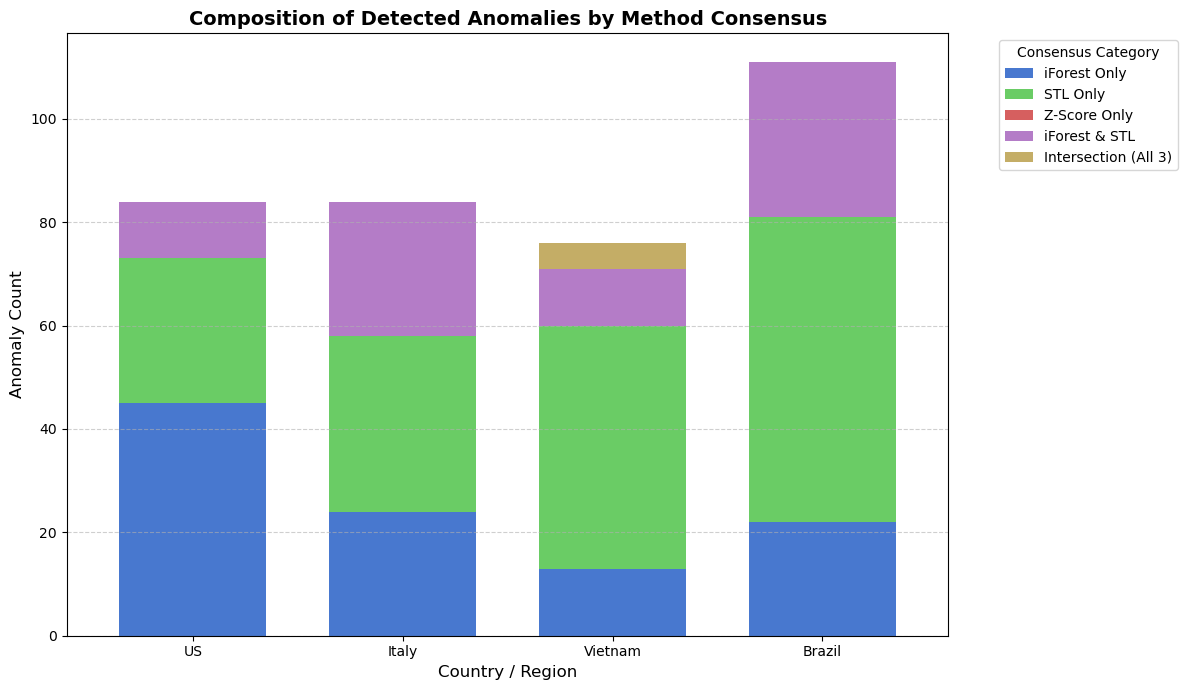

In [16]:
plt.style.use('seaborn-v0_8-muted') 
df_plot = df_overlap_stats.set_index('Country')

ax = df_plot.plot(kind='bar', stacked=True, figsize=(12, 7), width=0.7)

plt.title('Composition of Detected Anomalies by Method Consensus', fontsize=14, fontweight='bold')
plt.xlabel('Country / Region', fontsize=12)
plt.ylabel('Anomaly Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Consensus Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Mức độ trùng nhau cực kỳ thấp ở 3 phương pháp khi chỉ số **Intersection (All 3)** gần như bằng 0 ở hầu hết các quốc gia (ngoại trừ Việt Nam có 5 điểm). Điều này chứng minh rằng ba phương pháp này hoạt động trên các nguyên lý toán học hoàn toàn khác nhau và không có xu hướng phát hiện dị thường tại cùng một thời điểm. Bên cạnh đó lại có một lượng điểm chung nhất định (từ 11 đến 30 điểm) giữa **Isolation Forest** và **STL**. Đây có thể là những điểm dị thường vừa lệch khỏi xu hướng địa phương, vừa nằm trong vùng dữ liệu có mật độ biến động lớn.

Còn ở đặc điểm của các điểm dị thường riêng biệt: 
- Nhóm "iForest Only" thường xuất hiện nhiều nhất ở các quốc gia có sóng dịch biến động mạnh và phức tạp (như Mỹ với 45 điểm). Đây là các điểm phản ánh rõ sự hỗn loạn về phương sai, tại đây mật độ dữ liệu thay đổi đột ngột so với các giai đoạn bình ổn.
- Nhóm "STL Only" thì chiếm tỷ lệ cao nhất tại Brazil (59 điểm) và Việt Nam (47 điểm). Đây thường là các điểm thường phản ánh sai số báo cáo hoặc dồn số liệu y tế chứ không mang tính chất báo động cho cả một làn sóng dịch lớn.
- Nhóm "Z-Score Only" thì bằng 0 tuyệt đối ở tất cả các quốc gia, cho thấy hoàn toàn không có khả năng phát hiện thêm bất kỳ dị thường nào mà hai phương pháp kia chưa thấy, thể hiện độ tin cậy cực thấp ở bản thân thuật toán. 

### 2.5. Phân tích dị thường trên từng loại dữ liệu và quốc gia
Ở phần này, việc xác định xem dị thường tập trung chủ yếu ở loại dữ liệu nào (Ca mắc, Ca khỏi, hay Tử vong) và tại khu vực địa lý nào có thể giúp chúng ta hiểu được biến số nào trong bộ dữ liệu có độ nhiễu cao nhất hoặc chịu ảnh hưởng mạnh nhất bởi các biến cố dịch tễ.

Đầu tiên, chúng ta sẽ viết một hàm nhỏ để trích xuất cả 3 biến số `New_cases`, `New_deaths` và `New_recovered`.

In [17]:
def prepare_full_features(df, countries):
    df_filtered = df[df['Country'].isin(countries)].copy()
    
    df_grouped = df_filtered.groupby(['Country', 'Date'])[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()
    df_grouped = df_grouped.sort_values(by=['Country', 'Date'])
    
    df_grouped['New_cases'] = df_grouped.groupby('Country')['Confirmed'].diff().fillna(0).clip(lower=0)
    df_grouped['New_deaths'] = df_grouped.groupby('Country')['Deaths'].diff().fillna(0).clip(lower=0)
    df_grouped['New_recovered'] = df_grouped.groupby('Country')['Recovered'].diff().fillna(0).clip(lower=0)
    
    return df_grouped

In [18]:
df_p5 = prepare_full_features(df_raw, TARGET_COUNTRIES)

display(df_p5[['Country', 'Date', 'New_cases', 'New_deaths', 'New_recovered']].tail())

,Country,Date,New_cases,New_deaths,New_recovered
1075,Vietnam,2020-10-13,3.0,0.0,0.0
1076,Vietnam,2020-10-14,9.0,0.0,4.0
1077,Vietnam,2020-10-15,2.0,0.0,1.0
1078,Vietnam,2020-10-16,0.0,0.0,1.0
1079,Vietnam,2020-10-17,2.0,0.0,0.0


Tiếp theo là tính toán kết quả qua 2 vòng lặp

In [19]:
features_to_test = ['New_cases', 'New_deaths', 'New_recovered']
heatmap_data = []

In [20]:
for country in TARGET_COUNTRIES:
    df_country = df_p5[df_p5['Country'] == country].copy()
    
    dataset_p5 = TimeSeriesDataset(path=None, time_column='Date')
    dataset_p5.data = df_country
    
    for feature in features_to_test:
        dataset_p5.set_target(target_column=feature)
        
        detector = DetectOutlierTimeSeries(method='iforest', window_size=7, contamination='auto')
        
        old_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w') 
        try:
            dataset_p5.accept(detector)
            mask = detector.get_anomaly_mask()
        finally:
            sys.stdout = old_stdout
            
        num_anomalies = mask.sum()
        heatmap_data.append({
            'Country': country,
            'Feature': feature,
            'Anomalies': num_anomalies
        })
        
        print(f"[*] {country:<10} | Biến: {feature:<15} -> {num_anomalies:>3} dị thường")
        
df_heatmap = pd.DataFrame(heatmap_data)

[*] US         | Biến: New_cases       ->  56 dị thường
[*] US         | Biến: New_deaths      ->  57 dị thường
[*] US         | Biến: New_recovered   ->  14 dị thường
[*] Italy      | Biến: New_cases       ->  54 dị thường
[*] Italy      | Biến: New_deaths      ->  69 dị thường
[*] Italy      | Biến: New_recovered   ->  20 dị thường
[*] Vietnam    | Biến: New_cases       ->  29 dị thường
[*] Vietnam    | Biến: New_deaths      ->  38 dị thường
[*] Vietnam    | Biến: New_recovered   ->  38 dị thường
[*] Brazil     | Biến: New_cases       ->  52 dị thường
[*] Brazil     | Biến: New_deaths      ->  28 dị thường
[*] Brazil     | Biến: New_recovered   ->  28 dị thường


Để có thể hình dung trên 1 bức tranh tổng quát, ta sẽ chuyển DataFrame kết quả thành một Pivot Table, sau đó biểu diễn dữ liệu thu được trên Heatmap. Màu càng đậm (đỏ) chứng tỏ khu vực/biến số đó càng chứa nhiều điểm dị thường, phản ánh chất lượng thu thập dữ liệu bất ổn.

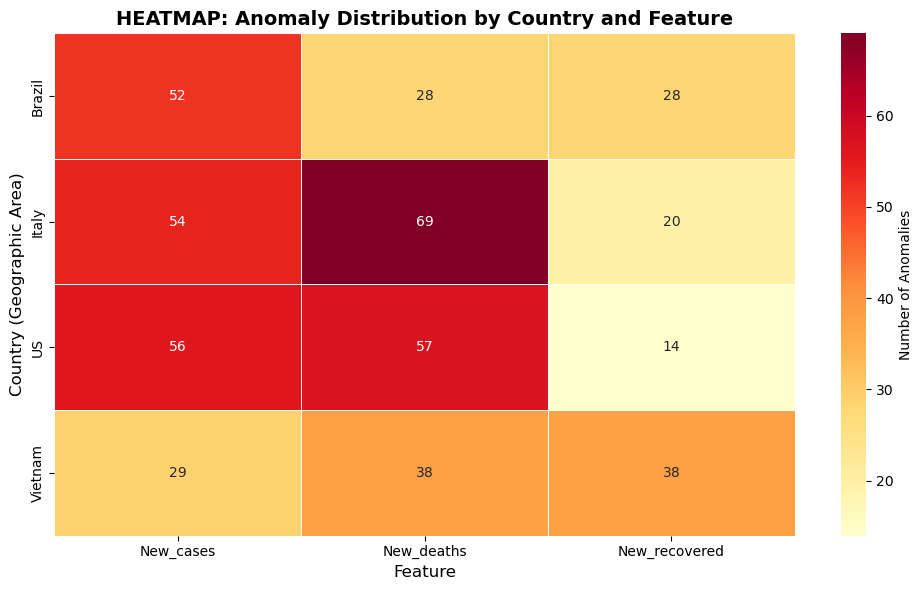

Feature,New_cases,New_deaths,New_recovered
Country,,,
Brazil,52,28,28
Italy,54,69,20
US,56,57,14
Vietnam,29,38,38


In [21]:
# Tạo Pivot Table
pivot_heat = df_heatmap.pivot(index='Country', columns='Feature', values='Anomalies')

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_heat, annot=True, fmt="d", cmap="YlOrRd", linewidths=.5, 
            cbar_kws={'label': 'Number of Anomalies'})

plt.title('HEATMAP: Anomaly Distribution by Country and Feature', fontsize=14, fontweight='bold')
plt.ylabel('Country (Geographic Area)', fontsize=12)
plt.xlabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

display(pivot_heat)

Có thể thấy:
- **Biến số nhiễu và biến động nhất là Số ca tử vong (Deaths) và Số ca mắc (Cases)**
    + Nếu cộng gộp trên toàn bộ 4 quốc gia, Số ca tử vong (192 điểm) và Số ca mắc mới (191 điểm) là hai nhóm dữ liệu chứa nhiều bất thường nhất. 
   + Đây là hai chỉ số rất quan trọng, chịu áp lực báo cáo công khai từng ngày. Vì vậy, chúng cực kỳ dễ bị tác động bởi các lỗi hành chính: trễ nhịp cuối tuần, nghẽn mạng lưới xét nghiệm, hoặc các đợt thanh tra dẫn đến việc cộng dồn/trừ đi hàng ngàn ca vào một ngày duy nhất. Điển hình là Ý với ghi nhận số điểm dị thường về tử vong cao kỷ lục (69 điểm), phản ánh hoàn toàn chính xác bối cảnh lịch sử thực tế ở giai đoạn đầu năm 2020, khi hệ thống y tế Ý vỡ trận, việc xét nghiệm và đếm số ca tử vong bị dồn ứ nghiêm trọng.
- **Biến số ổn định nhất là Số ca khỏi bệnh (Recovered)**
    + Trái ngược với sự hỗn loạn của hai biến trên, Số ca khỏi bệnh có tổng lượng dị thường thấp nhất (chỉ 100 điểm), đặc biệt là ở Mỹ (14 điểm) và Ý (20 điểm).
    + Nguyên nhân cho sự ổn định này không phải vì hệ thống đếm tốt hơn, mà thường là do là nó lại ít được quan tâm hơn. Trong thời kỳ đỉnh dịch, các bệnh viện dồn toàn lực vào cấp cứu và đếm ca tử vong/ca lây nhiễm, dẫn đến dữ liệu bệnh nhân khỏi bệnh thường không được cập nhật sát sao mỗi ngày. Vậy nên kết quả của biến số này có thể được tính từ các thuật toán y tế tự động ước tính (ví dụ như sau 14 ngày không có triệu chứng thì tự động tính là khỏi).
- Dù vậy, **một hiện tượng ngoại lệ đã xảy ra ở Việt Nam**. Việt Nam là quốc gia duy nhất đi ngược lại xu hướng toàn cầu trong bảng này với **điểm dị thường ở số ca khỏi (38) và tử vong (38) lại cao hơn số ca mắc (29)**. Điều này có thể phản ánh sự thành công của chiến lược "Zero Covid" được áp dụng ở giai đoạn 2020.

### 2.6. Đối chiếu dị thường với sự kiện thực tế
Phần này sẽ kiểm tra xem các điểm dị thường do thuật toán tìm ra là do bùng dịch thật hay chỉ là lỗi dồn báo cáo y tế, bằng cách trích xuất top 5 ngày có số ca mắc mới cao nhất từ tập hợp các điểm dị thường, từ đó đối chiếu với lịch sử báo chí để phân loại nguyên nhân thành 3 nhóm:
- **(A) Lỗi nhập liệu/Dồn báo cáo**: Thường rơi vào đầu tuần hoặc sau ngày lễ.
- **(B) Sự kiện lây nhiễm thực tế**: Đỉnh điểm của các làn sóng dịch.
- **(C) Thay đổi chính sách**: Mở rộng tiêu chí xét nghiệm.

In [25]:
consolidated_list = []

for country in TARGET_COUNTRIES:
    df_temp = df_daily[df_daily['Country'] == country].copy()
    
    df_temp['is_anomaly'] = all_masks['iforest'][country]
    
    consolidated_list.append(df_temp)

df_global_analysis = pd.concat(consolidated_list)

global_top_5 = df_global_analysis[df_global_analysis['is_anomaly']].sort_values(by='New_cases', ascending=False).head(5)
global_top_5['Day_Name'] = global_top_5['Date'].dt.day_name()

display(global_top_5[['Country', 'Date', 'Day_Name', 'New_cases']])

,Country,Date,Day_Name,New_cases
716,US,2020-07-16,Thursday,77362.0
724,US,2020-07-24,Friday,73107.0
717,US,2020-07-17,Friday,72010.0
722,US,2020-07-22,Wednesday,71305.0
729,US,2020-07-29,Wednesday,71302.0


Đây là bản kết quả đầy đủ kèm minh chứng lịch sử (có kèm nguồn trên Internet để đối chiếu).

In [26]:
root_cause_data = {
    'Country': ['US', 'US', 'US', 'US', 'US'],
    'Date': ['2020-07-16', '2020-07-24', '2020-07-17', '2020-07-22', '2020-07-29'],
    'Day_Name': ['Thursday', 'Friday', 'Friday', 'Wednesday', 'Wednesday'],
    'New_cases': [77362.0, 73107.0, 72010.0, 71305.0, 71302.0],
    'Root_Cause_Category': [
        '(B) Bùng phát thực tế',
        '(B) Bùng phát thực tế',
        '(B) Bùng phát thực tế',
        '(B) Bùng phát thực tế',
        '(B) Bùng phát thực tế'
    ],
    'Real_World_Event_Evidence': [
        'Mỹ lập kỷ lục thế giới về số ca mắc trong ngày, đánh dấu đỉnh điểm của làn sóng dịch mùa hè (Sun Belt Surge). Nguồn: https://www.nytimes.com/2020/07/16/world/coronavirus-updates.html',
        'Số ca mắc mới duy trì ở mức cực cao khi dịch bệnh lan rộng khắp các bang miền Nam và miền Tây nước Mỹ. Nguồn: https://www.theguardian.com/world/2020/jul/24/us-coronavirus-cases-california-florida-texas',
        'Làn sóng dịch bùng nổ mạnh mẽ khiến nhiều tiểu bang phải tái áp đặt các biện pháp hạn chế. Nguồn: https://www.bbc.com/news/world-us-canada-53450371',
        'Sự kiện lịch sử: California chính thức vượt qua New York để trở thành bang có nhiều ca nhiễm nhất nước Mỹ. Nguồn: https://www.reuters.com/article/us-health-coronavirus-usa-california-idUSKCN24N29X',
        'Tình trạng lây nhiễm trong cộng đồng ở mức báo động đỏ, gây áp lực khủng khiếp lên hệ thống xét nghiệm toàn quốc. Nguồn: https://www.cnbc.com/2020/07/29/us-coronavirus-cases-rise-as-death-toll-passes-150000.html'
    ]
}

df_root_cause_analysis = pd.DataFrame(root_cause_data)
pd.set_option('display.max_colwidth', None)

display(df_root_cause_analysis)

,Country,Date,Day_Name,New_cases,Root_Cause_Category,Real_World_Event_Evidence
0,US,2020-07-16,Thursday,77362.0,(B) Bùng phát thực tế,"Mỹ lập kỷ lục thế giới về số ca mắc trong ngày, đánh dấu đỉnh điểm của làn sóng dịch mùa hè (Sun Belt Surge). Nguồn: https://www.nytimes.com/2020/07/16/world/coronavirus-updates.html"
1,US,2020-07-24,Friday,73107.0,(B) Bùng phát thực tế,Số ca mắc mới duy trì ở mức cực cao khi dịch bệnh lan rộng khắp các bang miền Nam và miền Tây nước Mỹ. Nguồn: https://www.theguardian.com/world/2020/jul/24/us-coronavirus-cases-california-florida-texas
2,US,2020-07-17,Friday,72010.0,(B) Bùng phát thực tế,Làn sóng dịch bùng nổ mạnh mẽ khiến nhiều tiểu bang phải tái áp đặt các biện pháp hạn chế. Nguồn: https://www.bbc.com/news/world-us-canada-53450371
3,US,2020-07-22,Wednesday,71305.0,(B) Bùng phát thực tế,Sự kiện lịch sử: California chính thức vượt qua New York để trở thành bang có nhiều ca nhiễm nhất nước Mỹ. Nguồn: https://www.reuters.com/article/us-health-coronavirus-usa-california-idUSKCN24N29X
4,US,2020-07-29,Wednesday,71302.0,(B) Bùng phát thực tế,"Tình trạng lây nhiễm trong cộng đồng ở mức báo động đỏ, gây áp lực khủng khiếp lên hệ thống xét nghiệm toàn quốc. Nguồn: https://www.cnbc.com/2020/07/29/us-coronavirus-cases-rise-as-death-toll-passes-150000.html"
